In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

**Creating a sample dataset**

In [2]:
# Customers Table
customers = pd.DataFrame({
    "customer_id": [1, 2, 3, 4, 5],
    "customer_name": ["Alice", "Bob", "Charlie", "David", "Emma"],
    "region": ["North", "South", "East", "West", "North"],
    "segment": ["Consumer", "Corporate", "Consumer", "Home Office", "Corporate"]
})

# Products Table
products = pd.DataFrame({
    "product_id": [101, 102, 103, 104, 105],
    "product_name": ["Laptop", "Phone", "Tablet", "Monitor", "Keyboard"],
    "category": ["Electronics", "Electronics", "Electronics", "Accessories", "Accessories"],
    "price": [60000, 30000, 25000, 15000, 2000]
})

# Orders Table
orders = pd.DataFrame({
    "order_id": [1001,1002,1003,1004,1005,1006,1007,1008,1009,1010],
    "customer_id": [1,2,3,4,5,1,2,3,4,5],
    "product_id": [101,102,103,104,105,102,103,104,105,101],
    "quantity": [1,2,1,3,5,1,2,1,4,2],
    "order_date": pd.to_datetime([
        "2024-01-05","2024-01-10","2024-02-15","2024-02-20",
        "2024-03-05","2024-03-10","2024-04-12","2024-04-18",
        "2024-05-02","2024-05-15"
    ])
})

**Task1**

In [3]:
tables = {
    "Customers": customers,
    "Products": products,
    "Orders": orders
}

for name, df in tables.items():
    print(f"\n{name} Table")
    print("-"*50)
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nNull Values:")
    print(df.isnull().sum())

    print("\nDuplicates:", df.duplicated().sum())

    print("\nUnique Counts:")
    print(df.nunique())


Customers Table
--------------------------------------------------
Shape: (5, 4)

Columns:
['customer_id', 'customer_name', 'region', 'segment']

Data Types:
customer_id       int64
customer_name    object
region           object
segment          object
dtype: object

Null Values:
customer_id      0
customer_name    0
region           0
segment          0
dtype: int64

Duplicates: 0

Unique Counts:
customer_id      5
customer_name    5
region           4
segment          3
dtype: int64

Products Table
--------------------------------------------------
Shape: (5, 4)

Columns:
['product_id', 'product_name', 'category', 'price']

Data Types:
product_id       int64
product_name    object
category        object
price            int64
dtype: object

Null Values:
product_id      0
product_name    0
category        0
price           0
dtype: int64

Duplicates: 0

Unique Counts:
product_id      5
product_name    5
category        2
price           5
dtype: int64

Orders Table
-----------------

**Data Cleaning**

In [4]:
# Standardize column names

customers.columns = customers.columns.str.lower()
products.columns = products.columns.str.lower()
orders.columns = orders.columns.str.lower()

# Check missing values

for df in [customers, products, orders]:
    df.fillna("Unknown", inplace=True)

print("Cleaning Completed")

Cleaning Completed


**GroupBy Analysis**

In [5]:
merged = orders.merge(customers,on="customer_id") \
               .merge(products,on="product_id")

merged["revenue"] = merged["quantity"] * merged["price"]

sales_region = merged.groupby("region")["revenue"].sum()

print(sales_region)

region
East      40000
North    220000
South    110000
West      53000
Name: revenue, dtype: int64


In [6]:
sales_category = merged.groupby("category")["revenue"].sum()

print(sales_category)

category
Accessories     78000
Electronics    345000
Name: revenue, dtype: int64


In [7]:
sales_segment = merged.groupby("segment")["revenue"].sum()

print(sales_segment)

segment
Consumer       130000
Corporate      240000
Home Office     53000
Name: revenue, dtype: int64


In [8]:
multi_group = merged.groupby(
    ["region","category"]
)["revenue"].sum()

print(multi_group)

region  category   
East    Accessories     15000
        Electronics     25000
North   Accessories     10000
        Electronics    210000
South   Electronics    110000
West    Accessories     53000
Name: revenue, dtype: int64


**merge tables and metrics**

In [9]:
merged.head()

,order_id,customer_id,product_id,quantity,order_date,customer_name,region,segment,product_name,category,price,revenue
0,1001,1,101,1,2024-01-05,Alice,North,Consumer,Laptop,Electronics,60000,60000
1,1002,2,102,2,2024-01-10,Bob,South,Corporate,Phone,Electronics,30000,60000
2,1003,3,103,1,2024-02-15,Charlie,East,Consumer,Tablet,Electronics,25000,25000
3,1004,4,104,3,2024-02-20,David,West,Home Office,Monitor,Accessories,15000,45000
4,1005,5,105,5,2024-03-05,Emma,North,Corporate,Keyboard,Accessories,2000,10000


In [10]:
# total revenue
total_revenue = merged["revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 423000


In [11]:
# Average order value
avg_order_value = merged.groupby("order_id")["revenue"].sum().mean()

print("Average Order Value:", avg_order_value)

Average Order Value: 42300.0


In [12]:
# Top selling products
top_products = merged.groupby(
    "product_name"
)["revenue"].sum().sort_values(ascending=False)

print(top_products)

product_name
Laptop      180000
Phone        90000
Tablet       75000
Monitor      60000
Keyboard     18000
Name: revenue, dtype: int64


**Pivot tables**

In [13]:
# Region vs category
pivot1 = pd.pivot_table(
    merged,
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

pivot1

category,Accessories,Electronics
region,,
East,15000,25000
North,10000,210000
South,0,110000
West,53000,0


In [14]:
# Segment vs category
pivot2 = pd.pivot_table(
    merged,
    values="revenue",
    index="segment",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

pivot2

category,Accessories,Electronics
segment,,
Consumer,15000,115000
Corporate,10000,230000
Home Office,53000,0


**Six VIsualizations**

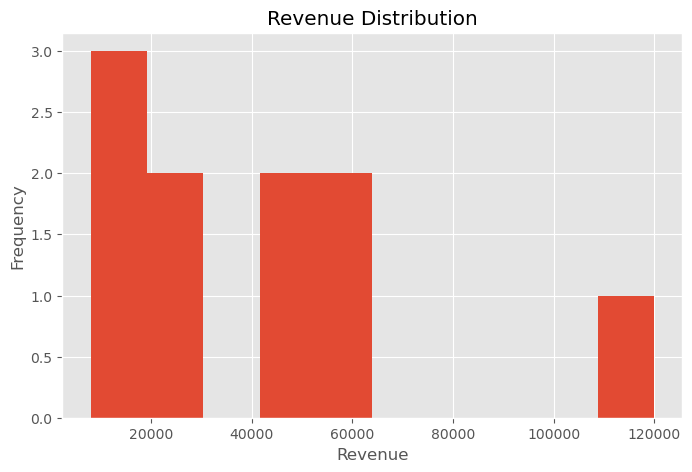

In [15]:
#Histogram
plt.figure(figsize=(8,5))
plt.hist(merged["revenue"], bins=10)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

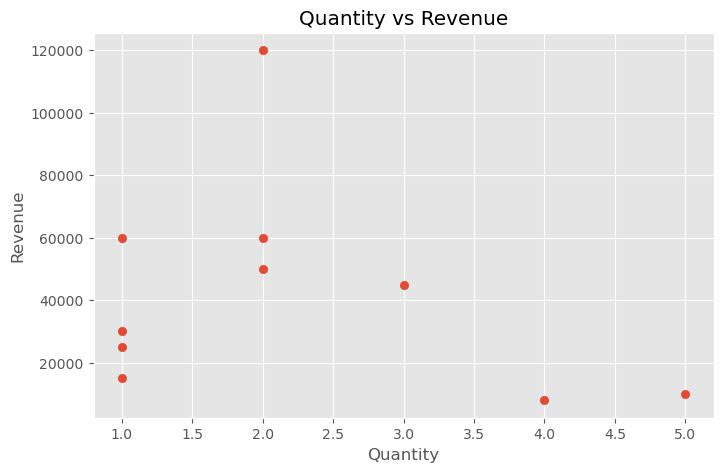

In [16]:
#Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(merged["quantity"], merged["revenue"])
plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

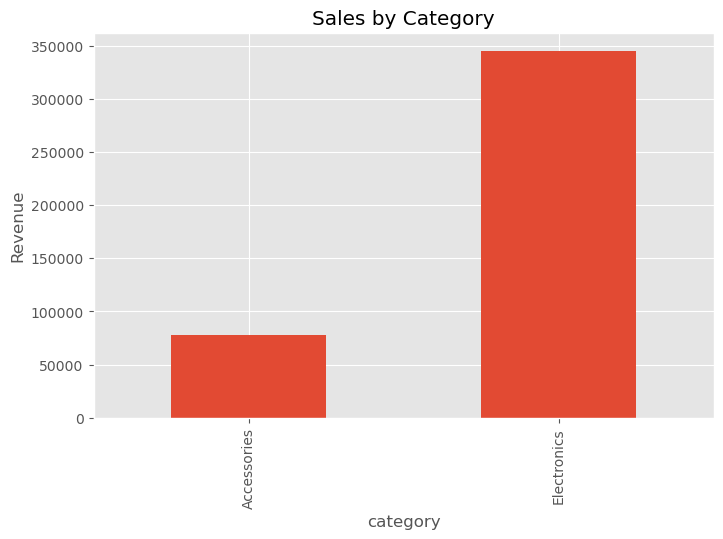

In [17]:
# Bar Chart
sales_category.plot(kind="bar", figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Revenue")
plt.show()

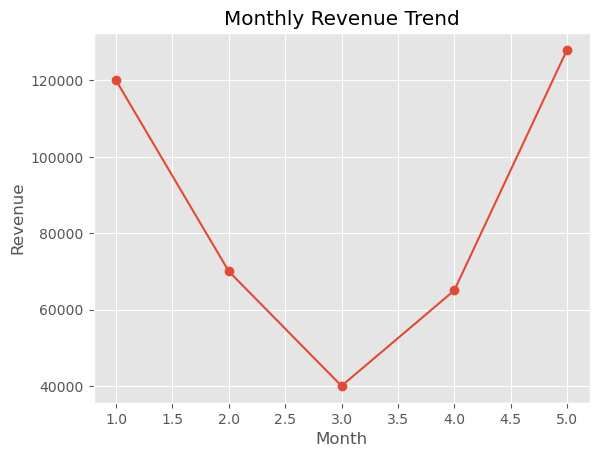

In [18]:
# Line chart
monthly_sales = merged.groupby(
    merged["order_date"].dt.month
)["revenue"].sum()

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

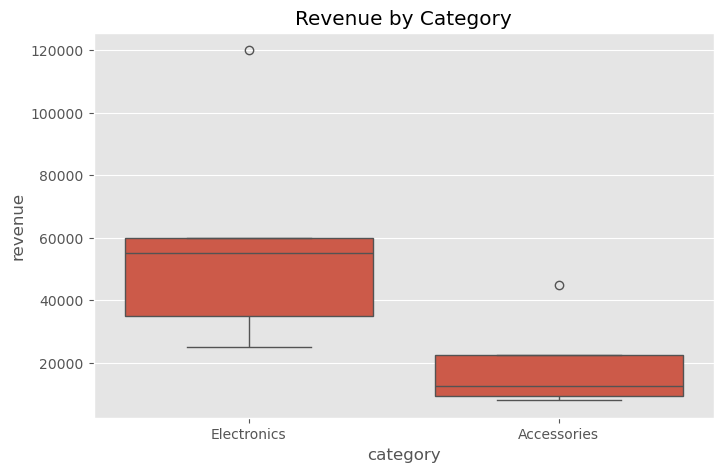

In [19]:
# Box Plot
plt.figure(figsize=(8,5))
sns.boxplot(x="category", y="revenue", data=merged)
plt.title("Revenue by Category")
plt.show()

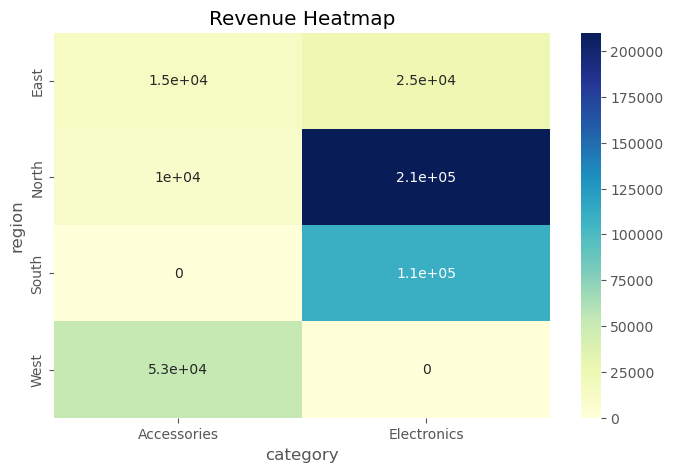

In [20]:
# Heat map
plt.figure(figsize=(8,5))
sns.heatmap(
    pivot1,
    annot=True,
    cmap="YlGnBu"
)
plt.title("Revenue Heatmap")
plt.show()

**Chart Stroy**

In [21]:
"""
1. Electronics generate significantly more revenue than Accessories.
2. Revenue increases during later months, showing business growth.
3. Higher quantities generally produce higher revenue.
4. North region contributes the largest revenue share.
5. Corporate customers generate strong sales compared to other segments.
6. Heatmap highlights strong electronics sales across all regions.
"""

'\n1. Electronics generate significantly more revenue than Accessories.\n2. Revenue increases during later months, showing business growth.\n3. Higher quantities generally produce higher revenue.\n4. North region contributes the largest revenue share.\n5. Corporate customers generate strong sales compared to other segments.\n6. Heatmap highlights strong electronics sales across all regions.\n'

In [22]:
conn = sqlite3.connect("sales.db")

customers.to_sql("customers", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)

cursor = conn.cursor()

In [25]:
query = """
SELECT *
FROM customers;
"""

result = pd.read_sql(query, conn)
print(result)

   customer_id customer_name region      segment
0            1         Alice  North     Consumer
1            2           Bob  South    Corporate
2            3       Charlie   East     Consumer
3            4         David   West  Home Office
4            5          Emma  North    Corporate


In [26]:
query = """
SELECT region,SUM(quantity)
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
GROUP BY region
"""

pd.read_sql(query, conn)

,region,SUM(quantity)
0,East,2
1,North,9
2,South,4
3,West,7


**Pandas vs SQL**

In [27]:
pandas_result = merged.groupby(
    "region"
)["revenue"].sum()

print(pandas_result)

region
East      40000
North    220000
South    110000
West      53000
Name: revenue, dtype: int64


In [28]:
sql_query = """
SELECT region,
SUM(quantity*price) AS revenue
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN products p
ON o.product_id=p.product_id
GROUP BY region
"""

sql_result = pd.read_sql(sql_query, conn)

print(sql_result)

  region  revenue
0   East    40000
1  North   220000
2  South   110000
3   West    53000


In [29]:
"""
Pandas:
- More flexible for data cleaning and transformations.
- Easier chaining of operations.
- Better integration with visualization.

SQL:
- Better for querying large databases.
- Efficient for joins and aggregations.
- More readable for business users familiar with SQL.

Both produce identical business results.
"""

'\nPandas:\n- More flexible for data cleaning and transformations.\n- Easier chaining of operations.\n- Better integration with visualization.\n\nSQL:\n- Better for querying large databases.\n- Efficient for joins and aggregations.\n- More readable for business users familiar with SQL.\n\nBoth produce identical business results.\n'